# [실습 3-2] 8-퍼즐 A\* — 휴리스틱 2종 성능 비교

| 항목 | 내용 |
|---|---|
| 예상 소요 시간 | 30~40분 (CPU 충분) |
| 본문 연계 | 3.3 정보 탐색과 휴리스틱 |
| 선수 실습 | [실습 3-1] 미로 탐색 (프론티어 개념 재사용) |
| 준비 | 부록 B.1·B.3 참고 |

8-퍼즐을 A\*로 풀면서, 휴리스틱의 "정확도"가 탐색량을
얼마나 줄이는지 **노드 확장 수**로 측정한다.

### [준비] 환경 설정 (저장소 전용)

In [1]:
# 저장소 루트를 임포트 경로에 추가
# (Colab에서는 아래 두 줄의 주석을 해제하고 실행)
# !git clone https://github.com/<저장소>/ai-intro-labs.git
# %cd ai-intro-labs/notebooks
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "utils").exists():
    ROOT = ROOT.parent          # ch03/에서 연 경우
sys.path.insert(0, str(ROOT))

import platform
import matplotlib
import numpy as np
from utils import plot_style, viz

plot_style.apply()              # 도해 스타일 킷 적용
print("Python", platform.python_version())
print("NumPy", np.__version__,
      "/ Matplotlib", matplotlib.__version__)

Python 3.12.6
NumPy 2.4.6 / Matplotlib 3.10.9


### [셀 1] 8-퍼즐 상태 표현과 이웃 상태 📖

In [2]:
GOAL = (1, 2, 3, 4, 5, 6, 7, 8, 0)   # 0 = 빈칸

def neighbors(state):
    """빈칸을 상하좌우로 밀어 만드는 다음 상태들."""
    s = list(state)
    i = s.index(0)
    r, c = divmod(i, 3)
    result = []
    for dr, dc in ((-1, 0), (1, 0), (0, -1), (0, 1)):
        nr, nc = r + dr, c + dc
        if 0 <= nr < 3 and 0 <= nc < 3:
            j = nr * 3 + nc
            s[i], s[j] = s[j], s[i]
            result.append(tuple(s))
            s[i], s[j] = s[j], s[i]
    return result

def show(state):
    """상태를 3x3 판으로 출력한다."""
    for k in range(0, 9, 3):
        print(state[k:k + 3])

show(GOAL)

(1, 2, 3)
(4, 5, 6)
(7, 8, 0)


**핵심 포인트**
- 상태 = 9칸의 타일 배열 **튜플**(불변이라 방문 기록의 키로 쓸 수 있다).
- "타일을 민다" 대신 "빈칸을 민다"로 생각하면 연산자가 최대 4개로 정리된다(3.1의 정형화).

기대 출력: 목표 상태의 3×3 판.

### [셀 2] 휴리스틱 2종 📖

In [3]:
def h1(state):
    """어긋난 타일 수 (빈칸 제외)."""
    return sum(1 for i, v in enumerate(state)
               if v != 0 and v != GOAL[i])

def h2(state):
    """맨해튼 거리 합 — 각 타일이 제자리까지 갈 거리."""
    total = 0
    for i, v in enumerate(state):
        if v == 0:
            continue
        r1, c1 = divmod(i, 3)
        r2, c2 = divmod(GOAL.index(v), 3)
        total += abs(r1 - r2) + abs(c1 - c2)
    return total

**핵심 포인트**
- 두 함수 모두 실제 남은 수를 **넘겨 짚지 않는다**(허용 가능, 3.3.2) → A\*의 최적성이 보장된다.
- h₂는 h₁보다 항상 크거나 같으면서 허용 가능하다 → h₂가 h₁을 **지배**한다(3.3.3). 이 차이가 탐색량에 어떻게 나타나는지 [셀 4]에서 측정한다.

### [셀 3] A\* 탐색 📖

In [4]:
import heapq

def astar(start, h):
    """A*: f = g + h. (경로, 노드 확장 수)를 반환한다."""
    frontier = [(h(start), 0, start)]
    parent, g = {start: None}, {start: 0}
    expanded = 0
    while frontier:
        _, cost, state = heapq.heappop(frontier)
        if state == GOAL:
            path = []
            while state is not None:
                path.append(state)
                state = parent[state]
            return path[::-1], expanded
        expanded += 1
        for nxt in neighbors(state):
            ng = cost + 1              # g: 지금까지 온 거리
            if nxt not in g or ng < g[nxt]:
                g[nxt], parent[nxt] = ng, state
                heapq.heappush(frontier,
                               (ng + h(nxt), ng, nxt))
    return [], expanded

**핵심 포인트**
- 프론티어가 **우선순위 큐**: f = g(온 거리) + h(남은 거리 추정)가 가장 작은 상태부터 꺼낸다.
- 더 짧은 경로로 같은 상태에 다시 도달하면 기록을 갱신한다(`ng < g[nxt]`).
- BFS/DFS와 뼈대는 같다 — 프론티어 자료구조만 세 번째로 바뀌었다.

### [셀 4] 난이도 3종 문제 생성과 성능 비교 📖

In [5]:
import random

def scramble(k, seed):
    """목표에서 k번 무작위로 밀어 문제를 만든다(재현성)."""
    random.seed(seed)
    state, prev = GOAL, None
    for _ in range(k):
        cands = [s for s in neighbors(state) if s != prev]
        state, prev = random.choice(cands), state
    return state

PUZZLES = {"쉬움": scramble(8, seed=3),
           "중간": scramble(20, seed=3),
           "어려움": scramble(40, seed=3)}

results = {"h1 어긋난 타일": {}, "h2 맨해튼": {}}
for label, start in PUZZLES.items():
    path1, n1 = astar(start, h1)
    path2, n2 = astar(start, h2)
    results["h1 어긋난 타일"][label] = n1
    results["h2 맨해튼"][label] = n2
    print(f"{label}: 최단 {len(path1) - 1}수, "
          f"확장 h1={n1:,} / h2={n2:,}")

쉬움: 최단 8수, 확장 h1=9 / h2=8
중간: 최단 16수, 확장 h1=559 / h2=34
어려움: 최단 22수, 확장 h1=9,410 / h2=613


**핵심 포인트**
- `seed` 고정으로 누가 실행해도 같은 문제가 나온다(재현성).
- 두 휴리스틱 모두 **같은 최단 수**를 찾는다(허용 가능 → 최적성 동일) — 차이는 오직 **탐색량**이다.

기대 출력: `어려움: 최단 22수, 확장 h1=9,410 / h2=613` — 문제가 어려울수록 격차가 벌어진다.

실패 시 대처: 몇 분이 지나도 끝나지 않으면 `scramble(40, ...)`의 40을 30으로 줄여 실행해 본다(저사양 환경).

### [셀 5] 노드 확장 수 그래프 📖

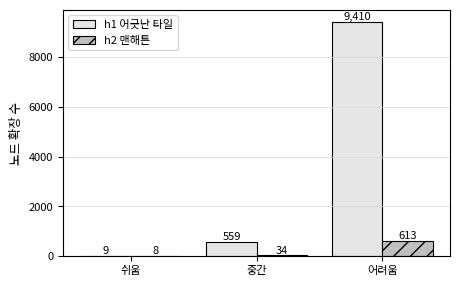

In [6]:
import matplotlib.pyplot as plt

viz.plot_heuristic_comparison(results)
plt.show()

**핵심 포인트**
- 어려움 문제에서 h₂(맨해튼)는 h₁의 **약 1/15**만 탐색한다 — "더 정확한 거리 감각 = 더 적은 탐색"(3.3.3)이 수치로 확인된다.
- 그래프 함수 본체는 `utils/viz.py`(지면 25줄 상한 — 코드 정책 ③).

### [보조 1] 해 경로 단계별 재생

In [7]:
path, _ = astar(PUZZLES["쉬움"], h2)
for step, state in enumerate(path):
    print(f"[{step}수]")
    show(state)
    print()

[0수]
(4, 1, 2)
(7, 5, 3)
(8, 6, 0)

[1수]
(4, 1, 2)
(7, 5, 3)
(8, 0, 6)

[2수]
(4, 1, 2)
(7, 5, 3)
(0, 8, 6)

[3수]
(4, 1, 2)
(0, 5, 3)
(7, 8, 6)

[4수]
(0, 1, 2)
(4, 5, 3)
(7, 8, 6)

[5수]
(1, 0, 2)
(4, 5, 3)
(7, 8, 6)

[6수]
(1, 2, 0)
(4, 5, 3)
(7, 8, 6)

[7수]
(1, 2, 3)
(4, 5, 0)
(7, 8, 6)

[8수]
(1, 2, 3)
(4, 5, 6)
(7, 8, 0)



### [심화 1] 새 휴리스틱 추가 (연습문제 심화 직결)

In [8]:
# 연습문제 심화: 새 휴리스틱을 설계해 h1·h2와 비교하자.
def h3(state):
    """(직접 설계) 예: h1과 h2의 평균, 또는
    맨해튼 거리 + 선형 충돌(같은 줄에서 순서가
    뒤바뀐 타일 쌍마다 +2) 등을 시도해 본다."""
    return 0        # TODO: 여기를 구현

# 구현 후 아래 주석을 해제해 세 휴리스틱을 비교한다.
# for label, start in PUZZLES.items():
#     _, n3 = astar(start, h3)
#     print(f"{label}: h3 확장 {n3:,}")
# 주의: h3가 실제 남은 수를 넘겨 짚으면(허용 불가)
#       최단성이 깨질 수 있다 — 왜 그런지 설명해 보자.

---
## 마무리

- A\*는 f = g + h로 "온 거리 + 남은 거리 추정"이 작은 곳부터 탐색한다 — 허용 가능한 휴리스틱이면 최단해를 보장한다.
- 휴리스틱이 정확할수록(h₂ ≻ h₁) 노드 확장 수가 급감한다 — 어려움 문제 기준 약 15배 차이.
- 좋은 휴리스틱 설계가 곧 정보 탐색의 성능이다.

**연습문제 연계**: [심화] "새로운 휴리스틱 추가 후 노드 확장 수 비교" 문항은 [심화 1] 셀 뼈대에서 바로 수행한다.

**다음 장 실습**: [실습 4-1] 미니 전방 연쇄 추론 엔진 (`ch04/lab-04-01_forward-chaining.ipynb`)